# Implementation from scratch - Gradient Descent (GD-Regressor class)

### Part-A (Logic for calculating b, m -> taken constant[same as OLS])

In [203]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.datasets import make_regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [204]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20)

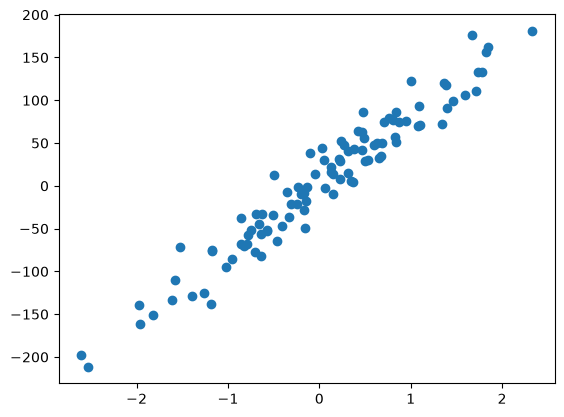

In [205]:
plt.scatter(X, y)

In [206]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [207]:
# Training on OLS

In [208]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[79.14]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.586
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[10.04]


In [209]:
model.coef_

array([79.13778212])

In [210]:
model.intercept_

np.float64(2.5864670459601053)

In [211]:
# Constructing the GD-Regressor class --
m = model.coef_[0]

In [212]:
class GDRegressor:

    def __init__(self, learning_rate, epochs):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.m = m
        self.b = -120

    def fit(self, X, y):
        
        # finding b using gradient descent

        for i in range(self.epochs):
            loss_slope = -2*np.sum(y - self.m*X.ravel() - self.b)
            step_size = self.learning_rate * loss_slope

            self.b = self.b - step_size
        
        print(self.m, self.b)

In [213]:
model1 = GDRegressor(0.001, 30000)
model1.fit(X, y)

79.13778212488687 2.586467045960107


In [214]:
# done :)

### Part-B (Logic for calculating both b and m)


In [215]:
model2 = LinearRegression()
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.9465023111392379

In [216]:
model2.coef_

array([78.33525525])

In [217]:
model2.intercept_

np.float64(2.589276561214547)

In [218]:
#Constructing the GD Regressor class

In [221]:
class GDRegressor2:

    def __init__(self, learning_rate, epochs):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.m = 200 #initial guess
        self.b = -120 #initial guess

    def fit(self, X_train, y_train):
        
        # finding b using gradient descent

        for i in range(self.epochs):
            loss_slope_b = -2*np.sum(y_train - self.m*X_train.ravel() - self.b)
            loss_slope_m = -2*np.sum((y_train - self.m*X_train.ravel() - self.b)*(X_train.ravel()))

            step_size_b = self.learning_rate * loss_slope_b
            step_size_m = self.learning_rate * loss_slope_m

            self.b = self.b - step_size_b
            self.m = self.m - step_size_m
        
        print(self.m, self.b)

    def predict(self, X_test):
        return self.m*X_test + self.b

In [222]:
model_gd = GDRegressor2(0.01, 30000)
model_gd.fit(X_train, y_train)

78.33525524716059 2.5892765612145467


In [223]:
y_pred2 = model_gd.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.9465023111392379

In [224]:
# done :)